In [1]:
from IPython.display import Image

# Part 1


### a: In your opinion, what were the most important turning points in the history of deep learning?


There are two things that come to mind from the lectures.

The first is the basics in terms of methodology and how deep learning is conducted, being The Perceptron, created in 1958 by Frank Rosenblatt.
This forms the basis for deep learning, with inspiration taken from an understanding of how neurons in the brain work (despite the two not at all being the same).
It takes an input, multiplies it by a weight (assumed strength of each nearby neuron), and then takes the sum of these to assign either a 1 or a zero to it as an activation function would. This is an icredibly simple classification method, assigning 1 or 0.

However time has built up on this method, implementing more input layers, and output layers leads to classification of more classes, not just the labels 0 and 1. Finally hidden layers have been added, making it possible to tuck in more mathematics such that it can solve more complicated problems.

Secondly there is the technological aspect that has been essential. The concept of AI winters was discussed, and Geoffrey Hintons comments on the errors needed to be solved to make it work being:
- Not enough data!
- Not enough computing power
- Weights initialised poorly (Still unsure what this means, but so too was Kaare)
- wrong type of non-linearity used.

Once these issues were rectified, (from a talk in 2016), we can clearly see the jump in abilities of deep learning.

### b: Explain the ADAM optimizer.

Adam utalises multiple techniques in its algorithm, it is built upon the following steps:

Starting with a Stochastic Gradient Descent on minibatched data (for computational efficiency), so it computes the gradient for a randomly sampled data point. The decay is controlled by a dynamic learning rate being reduced to help each iteration, as it would stagnate/hop around alot close to a minimum.

The next part is momentum, which helps convergence, as decreasing rapidly can stall convergence, and taking it too slow can have the noise interfer with a good solution.
The gradient computation is replaced with the "leaky average", also named the velocity.

$v_{t} = \beta_{1} V_{t-1} + (1- \beta_{1})g_{t}$

This accumulates past gradients and averages them, and is able to give a direction for the descent based on previous information as opposed to the gradient at a point.

$v_{t} = \sum_{\tau = 0}^{t-1} \beta^{\tau} g_{t- \tau , t - \tau - 1}$

This helps prevent stalling, and converges on solutions faster than the gradient at a point.

The final point is utilisation of RMSProp, where that can adapt the learning rates for each parameter by dividing it by the root of the mentioned $v_{t}$. This shrinks the rate for large gradient parameters, and increases it for small ones.


### c: Assume data input is a single 30x40 pixel image. First layer is a convolutional layer with 5 filters, with kernel size 3x2, step size (1,1) and padding='valid'. What are the output dimensions?

This is something that still confuses me, but I found the following formula to calculate this at [baeldung](https://www.baeldung.com/cs/convolutional-layer-size)

$W_{out} = \frac{W_{in} - K + 2 P}{S} + 1 $

$H_{out} = \frac{H_{in} - K + 2 P}{S} + 1 $

W and H is width and height respectively. K is filter of dimensions, S is stride, and P is padding.
As padding is valid, this value is 0, reducing the equation.

Pluggin in the values we get.

$W_{out} = \frac{30 - 3 + 2 \cdot 0}{1} + 1  = \frac{27}{1} + 1 = 28$

$H_{out} = \frac{40 - 2 + 2 \cdot 0}{1} + 1 = \frac{38}{1} + 1 = 39$

Thus the output dimensions are $(28, 39)$

It also says that there is a convolution layer with 5 filters. I understand this as there being 5 seperate filters with 5 outputs total, so it would increase the output dimension by $ x 5$

So the total output would be  $(28, 39, 5)$
This final part isnt in the link, and I am rather unsure.


### d: Assuming ReLU activations and offsets, and that the last layer is softmax, how many parameters does this network have:

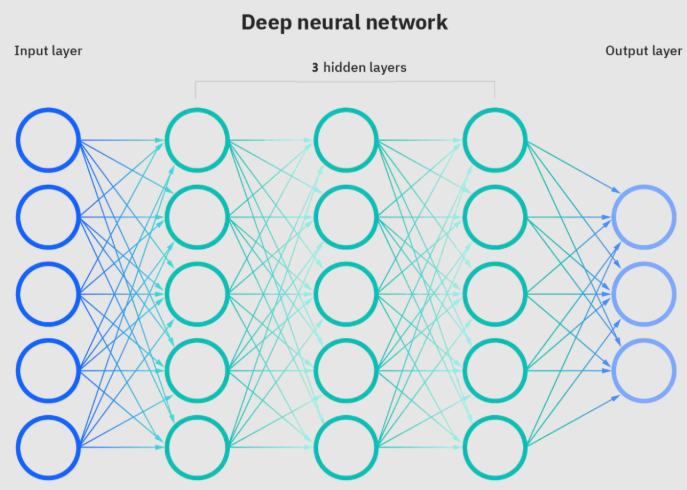

In [2]:
Image(filename='/home/stefan_stringer/FinalSemester/Deep Learning/Assignments/Assignment 1/A1_1.png')

TO calculate this I found the eqatuon at the following website [geeksforgeeks]('https://www.geeksforgeeks.org/deep-learning/how-to-calculate-the-number-of-parameters-in-cnn/).

$parameters = (input \cdot output) + output$

You sum this up for each layer and this gives:

$(5 x 5 + 5) + (5 x 5 + 5) +(5 x 5 + 5) +(5 x 5 x 3) = 30 + 30 + 30 + 18 = 108$

Thus, 108 parameters in the given network.

### e: For a given minibatch, the targets are [1,4, 5, 8] and the network output is [0.1,4.4,0.2,10]. If the loss function is "torch.nn.HuberLoss(reduction='mean', delta=1.0)", what is the loss for this minibatch?

Huber loss formula is taken from [geeksforgeeks]('https://www.geeksforgeeks.org/machine-learning/huber-loss-function-in-machine-learning/).


$$
\text{Loss}(a) = 
\begin{cases}
\frac{1}{2}a^2 & \text{if } |a| \leq \delta \\
\delta(|a| - \frac{1}{2}\delta) & \text{if } |a| > \delta
\end{cases}
$$

Where $a = |\text{prediction} - \text{target}|$ and $\delta$ is a threshold parameter at 1.0

I do not want to write this all fully out, so I name the minibatch tagerts as $[a, b, c, d]$

First
$ a_a = 0.9 $
$L_a = 0.5 \cdot 0.9 ^ 2 = 0.405 $

Second
$ a_b = 0.4 $
$L_b = 0.5 \cdot 0.4 ^ 2 = 0.08 $

Third
$ a_c = 4.8 $
$L_c = 1.0 \cdot (4.8 - 0.5 \cdot 1.0) = 4.3 $

Fourth
$ a_d = 2.0 $
$L_d = 1.0 \cdot (2.0 - 0.5 \cdot 1.0) = 1.5$

Now calulcate the mean loss

$L_{mean} = \frac{0.405 + 0.08 + 4.3 + 1.5}{4} = \frac{6.285}{4} = 1.57125$


# Part 2: Writing a PyTorch Dataset

First I need to make a class for taking the Insect Dataset, taking inspiration from w2.ipynb CustomeImageDataset class.

In [1]:
#this is made with reference to the tutorial https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
import os
import pandas as pd
from torch.utils.data import Dataset
from torchvision.io import decode_image
import torchvision.transforms as transforms
#custom class here is mostly identical to the tutorial, bar a few small changes.
class InsectDataset(Dataset):
    #init method is the same as tutorial.
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
    
    #len method is the same.
    def __len__(self):
        return len(self.img_labels)
    
    #getitem method is almost the same, the difference being that we hardcode the columns wanted from the .csv file.
    def __getitem__(self, idx):
        img_filename = self.img_labels.iloc[idx, 2] #looking at the .csv can see that column 2 is the image filename
        species_label = self.img_labels.iloc[idx, 1] # here can see that column 1 is the species label
        
        img_path = os.path.join(self.img_dir, img_filename)
        image = decode_image(img_path) 
        
        if self.transform:
            image = self.transform(image)
        
        if self.target_transform:
            species_label = self.target_transform(species_label)
        
        return image, species_label

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
#Lets test the dataset in the notebook
transform = transforms.Compose([
    transforms.Resize((224, 224)), #Resize the images to 224x224 pixels as some were mismatched in size.
])

insect_dataset = InsectDataset(# YOUR DATASET HERE
    annotations_file='/home/stefan_stringer/FinalSemester/Deep Learning/Assignments/Assignment 1/insects.csv',
    img_dir='/home/stefan_stringer/FinalSemester/Deep Learning/Assignments/Assignment 1/Insects',
    transform=transform
)
# Here i have a print statement to ensure that its given just like how it says in the assignment example description. Minor sanity check. This was placed at the end of dataset_tester.py
for i in range(5):
    image, label = insect_dataset[i]
    print(f"<image data from {insect_dataset.img_labels.iloc[i, 2]}>,  {label}")

<image data from 2_003311_1_2020_05_09-14-21-01-959.jpg>,  Andrena fulva
<image data from 2_003311_1_2020_05_09-14-21-01-929.jpg>,  Andrena fulva
<image data from 2_003311_1_2020_05_09-14-21-01-608.jpg>,  Andrena fulva
<image data from 1_003311_1_2020_05_09-14-21-02-531.jpg>,  Andrena fulva
<image data from 1_003311_1_2020_05_09-14-21-02-266.jpg>,  Andrena fulva


# Part 3

### We supply two datasets, with points drawn from a 2D feature space, and a label assigned to each data point. The data has already been assigned to train and test sets. Each file is a table, where first column is the label, and the 2nd and 3rd columns are the features.

### a: describe & visualize the data

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load both the training and test txt data
train_df = pd.read_csv('trainData.txt', header=None, sep='\s+')
test_df = pd.read_csv('testData.txt', header=None, sep='\s+')

train_X = train_df.iloc[:, 1:3].values.astype(np.float32)
train_y = train_df.iloc[:, 0].values.astype(int)
test_X = test_df.iloc[:, 1:3].values.astype(np.float32)
test_y = test_df.iloc[:, 0].values.astype(int)
# test_X

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_47404/451011127.py:2: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('trainData.txt', header=None, sep='\s+')
/tmp/ipykernel_47404/451011127.py:3: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('testData.txt', header=None, sep='\s+')


In [3]:
print(f"Training samples: {len(train_X)}")
print(f"Test samples: {len(test_X)}")
print(f"Features per sample: {train_X.shape[1]}")
print(f"Number of unique classes: {len(np.unique(train_y))}")
print(f"Class values: {np.unique(train_y)}")

Training samples: 1200
Test samples: 299
Features per sample: 2
Number of unique classes: 5
Class values: [0 1 2 3 4]


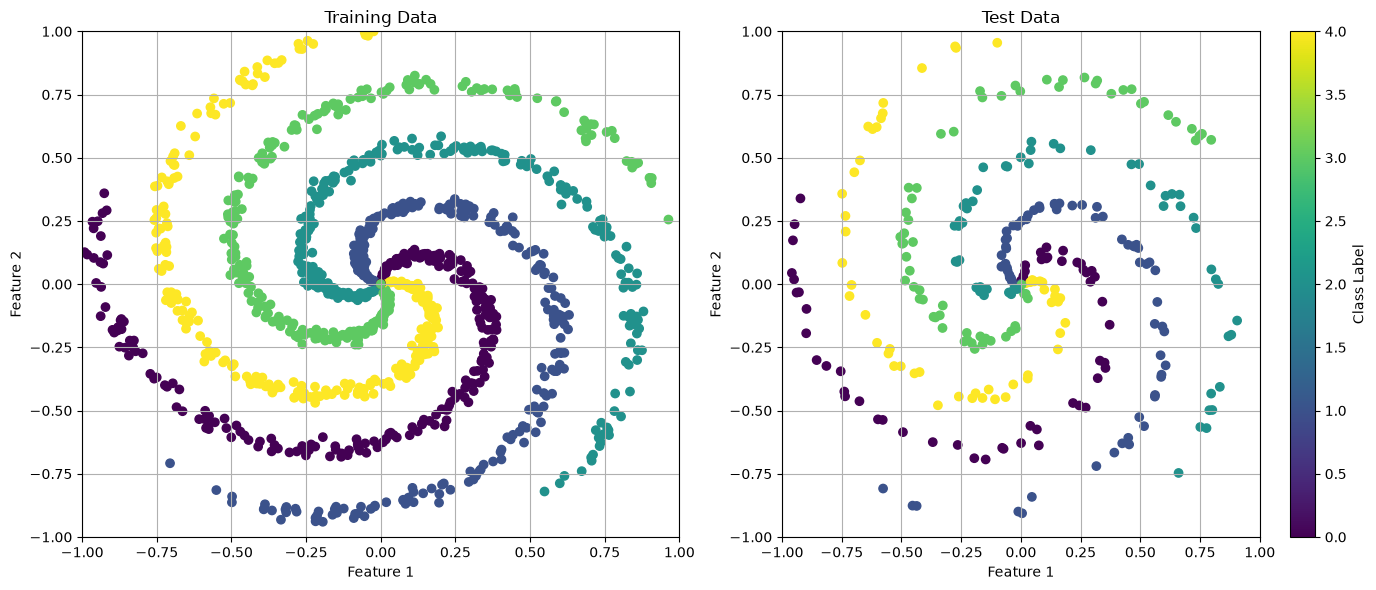

In [4]:
#Plot to hav a look at the data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train_plot = axes[0].scatter(train_X[:, 0], train_X[:, 1], c=train_y, cmap='viridis')
axes[0].set_title('Training Data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid()

test_plot = axes[1].scatter(test_X[:, 0], test_X[:, 1], c=test_y, cmap='viridis')
axes[1].set_title('Test Data')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid()
plt.colorbar(test_plot, ax=axes[1], label='Class Label')

axes[0].set_xlim([-1, 1])
axes[0].set_ylim([-1, 1])
axes[1].set_xlim([-1, 1])
axes[1].set_ylim([-1, 1])
plt.tight_layout()
plt.show()

The data we have is saved in .txt files, where there are 3 columns. The three features provided are in order of columns, the class/label which is just a whole int of either 0, 1, 2, 3, 4, then the next two columns are values between [-1, 1]. This could be a value for anything, but after plotting them, as seen in the figures for both test and train datasets above, it is shown that they are coordinate positions to form this spiral pattern.
The training data contains far more points, as is expected compared to the test data.
Now that I know how the data looks, and there is a visual interpretation to the data as opposed to specific information pertaining to each feature, I can now make a networ an trian on the data to assign the labels corerctly to each arm in the spiral.

### b: design a neural network using pytorch to correctly assign labels 

Describe your network

Describe your training strategy

Describe your results and discuss the observed performance

Visualize network performance similar to: (given in assignment page on brightspace)

In [5]:
#Prep the data
train_X_t = torch.tensor(train_X)
train_y_t = torch.tensor(train_y)
test_X_t = torch.tensor(test_X)
test_y_t = torch.tensor(test_y)

number_of_classes = len(np.unique(train_y))

batch_size = 64
train_dataset = TensorDataset(train_X_t, train_y_t)
test_dataset = TensorDataset(test_X_t, test_y_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# Modification of class used in computation physics class
class spiralArmClassifier(nn.Module):
    def __init__(self, Width=32, depth=4, number_of_classes=number_of_classes):
        super().__init__()
        layers = []
        
        # First layer: 2 input features where width is hidden neurons
        layers.append(nn.Linear(2, Width))
        layers.append(nn.SiLU())
        
        # Middle hidden layers (depth - 2 times)
        for _ in range(depth - 2):
            layers.append(nn.Linear(Width, Width))
            layers.append(nn.SiLU())
        
        # OUTPUT LAYER IS THE SAME AS THE NUMBER OF CLASSES
        layers.append(nn.Linear(Width, number_of_classes))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)
        
    def forward(self, x):
        return self.net(x)

In [7]:
model = spiralArmClassifier(Width=32, depth=4, number_of_classes=number_of_classes)

In [8]:
#Training part
criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr = 0.001)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

def train_epoch(model, loader, criterion, optimiser):
    model.train()
    total_loss, correct = 0, 0
    
    for X, y in loader:
        optimiser.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimiser.step()
        
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
    
    average_loss = total_loss / len(loader)
    average_acc = correct / len(loader.dataset)
    
    return average_loss, average_acc

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in loader:
            pred = model(X)
            loss = criterion(pred, y)
            
            total_loss += loss.item()
            correct += (pred.argmax(1) == y).sum().item()
    
    average_loss = total_loss / len(loader)
    average_acc = correct / len(loader.dataset)
    
    return average_loss, average_acc

In [9]:
#Here we train the model:

epochs = 100

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimiser)
    test_loss, test_acc = eval_epoch(model, test_loader, criterion)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/100 - Train Loss: 1.6117, Train Acc: 0.2150, Test Loss: 1.5979, Test Acc: 0.2575
Epoch 2/100 - Train Loss: 1.5988, Train Acc: 0.2767, Test Loss: 1.5858, Test Acc: 0.3244
Epoch 3/100 - Train Loss: 1.5785, Train Acc: 0.2608, Test Loss: 1.5587, Test Acc: 0.2676
Epoch 4/100 - Train Loss: 1.5411, Train Acc: 0.2592, Test Loss: 1.5118, Test Acc: 0.2609
Epoch 5/100 - Train Loss: 1.4913, Train Acc: 0.2567, Test Loss: 1.4587, Test Acc: 0.2642
Epoch 6/100 - Train Loss: 1.4490, Train Acc: 0.2750, Test Loss: 1.4254, Test Acc: 0.2441
Epoch 7/100 - Train Loss: 1.4295, Train Acc: 0.2608, Test Loss: 1.4106, Test Acc: 0.2441
Epoch 8/100 - Train Loss: 1.4224, Train Acc: 0.2692, Test Loss: 1.4089, Test Acc: 0.2542
Epoch 9/100 - Train Loss: 1.4184, Train Acc: 0.2667, Test Loss: 1.3997, Test Acc: 0.2508
Epoch 10/100 - Train Loss: 1.4122, Train Acc: 0.2683, Test Loss: 1.3924, Test Acc: 0.2508
Epoch 11/100 - Train Loss: 1.4084, Train Acc: 0.2717, Test Loss: 1.3841, Test Acc: 0.2642
Epoch 12/100 - Trai

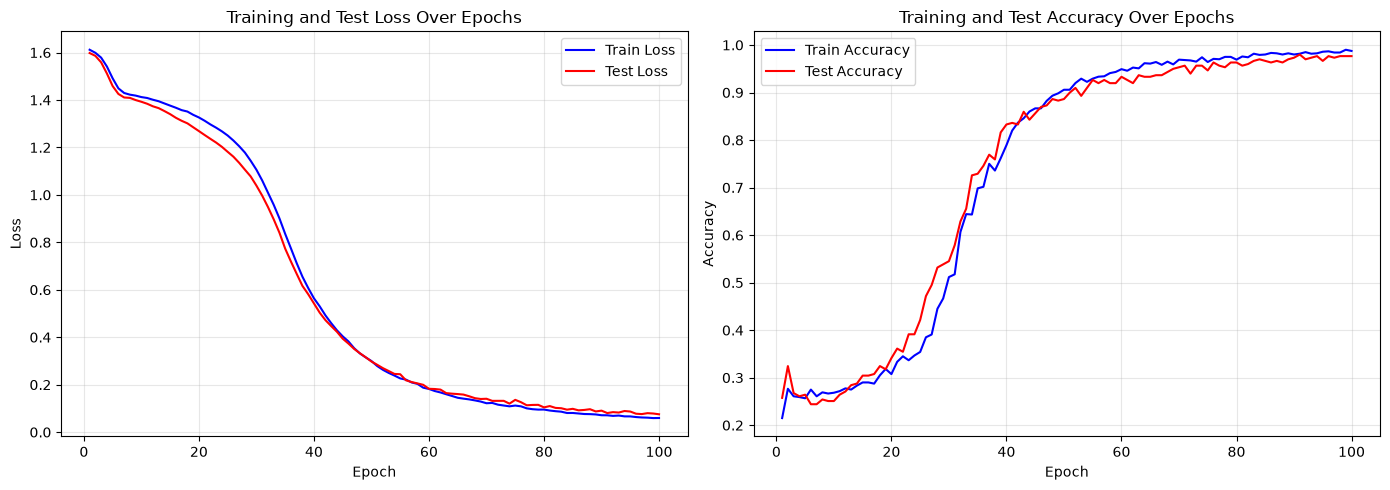

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, epochs+1), train_losses, 'b-', label='Train Loss')
axes[0].plot(range(1, epochs+1), test_losses, 'r-', label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs+1), train_accs, 'b-', label='Train Accuracy')
axes[1].plot(range(1, epochs+1), test_accs, 'r-', label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

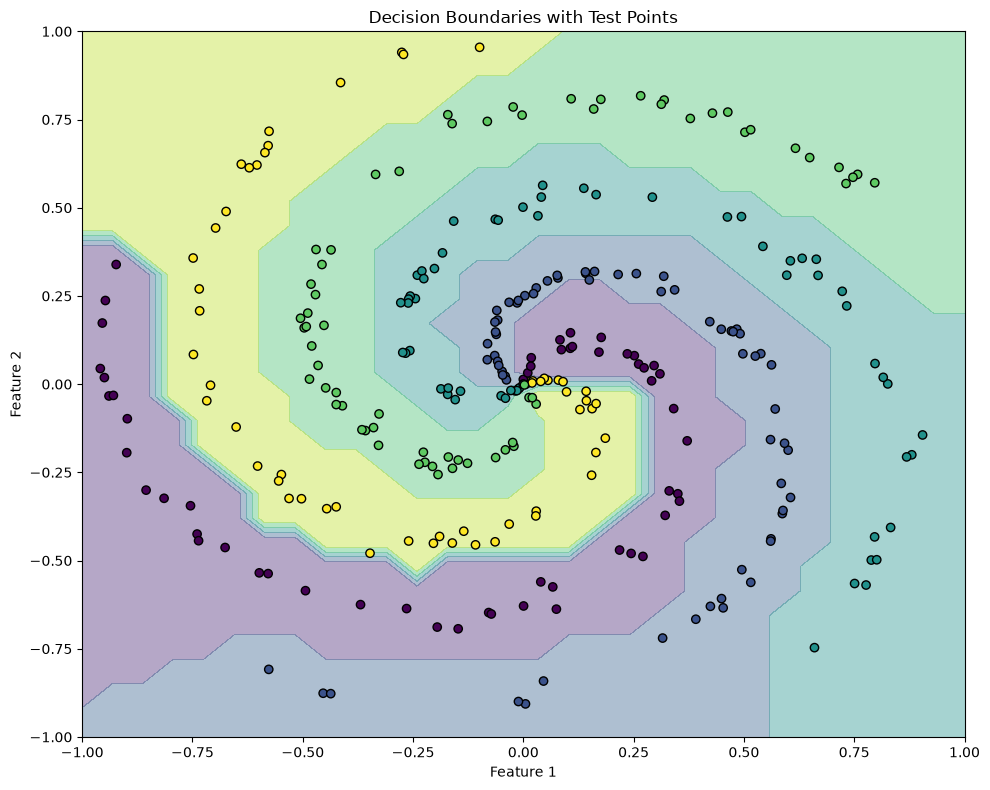

In [11]:
#visualise nerwork preformance part, with the code taken from assignment description and then modified still.

model.cpu()
x, y = np.meshgrid(np.linspace(-1, 1, 30), np.linspace(-1, 1, 30))
xy = np.concatenate((x.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
z = model(torch.tensor(xy).float()).detach().numpy()
z = np.argmax(z, 1).reshape(30, 30)

plt.figure(figsize=(10, 8))
contour = plt.contourf(x, y, z, alpha=0.4, cmap='viridis', levels=number_of_classes)
scatter = plt.scatter(test_X[:, 0], test_X[:, 1], c=test_y, cmap='viridis', edgecolors='black')#, 
                    #   s=60, edgecolors='black', linewidth=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundaries with Test Points')
plt.tight_layout()
plt.show()

In [ ]:
# Final report
final_train_loss, final_train_acc = evaluate_epoch(model, train_loader, criterion)
final_test_loss, final_test_acc = evaluate_epoch(model, test_loader, criterion)

print(f"FINAL PERFORMANCE:")
print(f"  Training Accuracy: {final_train_acc*100:.2f}%")
print(f"  Test Accuracy: {final_test_acc*100:.2f}%")
print(f"  Best Test Accuracy (saved model): {best_test_acc*100:.2f}%")
print(f"  Performance Gap: {(final_train_acc - final_test_acc)*100:.2f}%")
print()

NameError: name 'evaluate_epoch' is not defined